# Gold Layer — Joined & Aggregated Data + EDA

## Retail Banking Environment — Customer Financial Behaviour Analysis

### Context
This notebook is **Part 3 of 3** in our group project medallion pipeline.

- **Part 1 (Bronze)** — Raw mock banking data was generated (customers, accounts, transactions, loan_applications)
- **Part 2 (Silver)** — Data was cleaned, standardized, and validated
- **Part 3 (Gold) — This notebook** — Silver tables are joined and aggregated into analytical Gold tables, then explored through EDA

### What This Notebook Does
1. Load all Silver tables from `sandbox_catalog.banking_details`
2. Create two Gold tables:
   - **`transactions_gold`** — Enriched transaction-level data with customer and account details
   - **`customer_gold`** — Customer-level aggregations with complete financial profile
3. Perform Exploratory Data Analysis (EDA) with visualizations:
   - KPI summary
   - Transaction patterns by type and category
   - Customer segmentation analysis
   - Loan application insights
   - Age and income distribution
   - Correlation analysis

> **Note:** All Gold tables use the same catalog/schema as Bronze and Silver. The Gold layer is optimized for analytics and reporting.

---
## Imports & Configuration

In [0]:
import logging

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ── Logging setup ──────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("gold")

# ── Plot defaults ──────────────────────────────────────────
plt.rcParams["figure.dpi"]        = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# ── Catalog / schema constants ─────────────────────────────────
CATALOG = "sandbox_catalog"
SCHEMA  = "banking_details"

log.info("Imports complete. Catalog=%s  Schema=%s", CATALOG, SCHEMA)

20:34:56  INFO  Imports complete. Catalog=sandbox_catalog  Schema=banking_details


---
## Helper Functions

In [0]:
def read_table(table_name: str):
    """
    Read a Delta table from the active catalog/schema.
    Returns a Spark DataFrame.
    """
    full_name = f"{CATALOG}.{SCHEMA}.{table_name}"
    df = spark.read.table(full_name)
    log.info("Loaded %s (%d rows)", full_name, df.count())
    return df


def write_table(df, table_name: str, mode: str = "overwrite") -> None:
    """
    Write a Spark DataFrame as a Delta table.
    Uses overwrite mode by default for idempotency.
    """
    full_name = f"{CATALOG}.{SCHEMA}.{table_name}"
    df.write.format("delta").mode(mode).saveAsTable(full_name)
    log.info("Written %s (%d rows)", full_name, df.count())


log.info("Helper functions defined.")

20:34:57  INFO  Helper functions defined.


---
## Gold Layer — Joined & Aggregated Data

We produce two Gold tables:
- **`transactions_gold`** — Enriched transaction-level data with customer demographics and account details
- **`customer_gold`** — Customer-level aggregations with complete financial profile

### Read Silver Tables

In [0]:
# Reload the Silver tables as the starting point for Gold aggregations
customers_s   = read_table("customers_silver")
accounts_s    = read_table("accounts_silver")
transactions_s = read_table("transactions_silver")
loan_applications_s = read_table("loan_applications_silver")

20:35:32  INFO  Loaded sandbox_catalog.banking_details.customers_silver (1000 rows)
20:35:34  INFO  Loaded sandbox_catalog.banking_details.accounts_silver (1500 rows)
20:35:36  INFO  Loaded sandbox_catalog.banking_details.transactions_silver (9691 rows)
20:35:37  INFO  Loaded sandbox_catalog.banking_details.loan_applications_silver (558 rows)


### Build `transactions_gold`

Enrich transactions with customer demographics and account information.

In [0]:
# Join transactions -> accounts -> customers to build enriched transaction table
# This provides a complete view of each transaction with customer context

transactions_gold = (
    transactions_s
    .join(
        accounts_s.select("account_id", "customer_id", "account_type", 
                          "status", "open_date", "balance"),
        on="account_id",
        how="inner",
    )
    .join(
        customers_s.select("customer_id", "age", "province", 
                           "income_bracket", "join_date"),
        on="customer_id",
        how="inner",
    )
    # Add derived columns for analysis
    .withColumn("transaction_year", F.year("transaction_date"))
    .withColumn("transaction_month", F.month("transaction_date"))
    .withColumn("transaction_quarter", F.quarter("transaction_date"))
    # Calculate days since account opening
    .withColumn("days_since_account_open", 
                F.datediff(F.col("transaction_date"), F.col("open_date")))
    # Customer tenure at time of transaction
    .withColumn("customer_tenure_days",
                F.datediff(F.col("transaction_date"), F.col("join_date")))
)

log.info("transactions_gold built with %d rows", transactions_gold.count())
display(transactions_gold.limit(5))

20:35:51  INFO  transactions_gold built with 9691 rows


customer_id,account_id,transaction_id,transaction_type,transaction_date,amount,merchant_category,account_type,status,open_date,balance,age,province,income_bracket,join_date,transaction_year,transaction_month,transaction_quarter,days_since_account_open,customer_tenure_days
1,79,0,withdrawal,2024-05-22,2317.08,ATM Withdrawal,chequing,inactive,2018-07-14,235147,28,QC,$100K-$150K,2024-07-30,2024,5,2,2139,-69
735,426,1,transfer,2024-01-04,2572.32,null,savings,inactive,2018-07-14,972710,29,BC,$100K-$150K,2017-03-02,2024,1,1,2000,2499
282,265,2,withdrawal,2024-05-11,1708.95,Online Shopping,savings,active,2018-07-14,13264,30,BC,$200K+,2026-03-25,2024,5,2,2128,-683
617,525,3,withdrawal,2024-11-24,323.32,Entertainment,chequing,active,2018-07-14,730596,27,PE,$25K-$50K,2018-06-16,2024,11,4,2325,2353
778,363,4,withdrawal,2024-12-31,4136.8,ATM Withdrawal,chequing,inactive,2018-07-14,358624,21,PE,$25K-$50K,2024-08-01,2024,12,4,2362,152


### Build `customer_gold`

Aggregate customer-level metrics from transactions, accounts, and loan applications.

In [0]:
# Step 1: Aggregate transaction behavior per customer
transaction_agg = (
    transactions_gold
    .groupBy("customer_id")
    .agg(
        F.count("transaction_id").alias("total_transactions"),
        F.sum("amount").alias("total_transaction_amount"),
        F.avg("amount").alias("avg_transaction_amount"),
        F.max("transaction_date").alias("last_transaction_date"),
        # By transaction type
        F.sum(F.when(F.col("transaction_type") == "deposit", F.col("amount")).otherwise(0)).alias("total_deposits"),
        F.sum(F.when(F.col("transaction_type") == "withdrawal", F.col("amount")).otherwise(0)).alias("total_withdrawals"),
        F.sum(F.when(F.col("transaction_type") == "transfer", F.col("amount")).otherwise(0)).alias("total_transfers"),
        # Count by transaction type
        F.sum(F.when(F.col("transaction_type") == "deposit", 1).otherwise(0)).alias("count_deposits"),
        F.sum(F.when(F.col("transaction_type") == "withdrawal", 1).otherwise(0)).alias("count_withdrawals"),
        F.sum(F.when(F.col("transaction_type") == "transfer", 1).otherwise(0)).alias("count_transfers"),
    )
    .withColumn("total_transaction_amount", F.round("total_transaction_amount", 2))
    .withColumn("avg_transaction_amount", F.round("avg_transaction_amount", 2))
    .withColumn("total_deposits", F.round("total_deposits", 2))
    .withColumn("total_withdrawals", F.round("total_withdrawals", 2))
    .withColumn("total_transfers", F.round("total_transfers", 2))
)

# Step 2: Aggregate account information per customer
account_agg = (
    accounts_s
    .groupBy("customer_id")
    .agg(
        F.count("account_id").alias("total_accounts"),
        F.sum("balance").alias("total_balance"),
        F.avg("balance").alias("avg_balance"),
        F.sum(F.when(F.col("account_type") == "chequing", 1).otherwise(0)).alias("count_chequing"),
        F.sum(F.when(F.col("account_type") == "savings", 1).otherwise(0)).alias("count_savings"),
        F.sum(F.when(F.col("status") == "active", 1).otherwise(0)).alias("active_accounts"),
    )
    .withColumn("total_balance", F.round("total_balance", 2))
    .withColumn("avg_balance", F.round("avg_balance", 2))
)

# Step 3: Aggregate loan information per customer
loan_agg = (
    loan_applications_s
    .groupBy("customer_id")
    .agg(
        F.count("application_id").alias("total_loan_applications"),
        F.sum("amount_requested").alias("total_amount_requested"),
        F.avg("interest_rate").alias("avg_interest_rate"),
        F.sum(F.when(F.col("status") == "approved", 1).otherwise(0)).alias("approved_loans"),
        F.sum(F.when(F.col("status") == "denied", 1).otherwise(0)).alias("denied_loans"),
        F.sum(F.when(F.col("status") == "pending", 1).otherwise(0)).alias("pending_loans"),
    )
    .withColumn("total_amount_requested", F.round("total_amount_requested", 2))
    .withColumn("avg_interest_rate", F.round("avg_interest_rate", 2))
)

# Step 4: Join everything together with customer demographics
customer_gold = (
    customers_s
    .join(transaction_agg, on="customer_id", how="left")
    .join(account_agg, on="customer_id", how="left")
    .join(loan_agg, on="customer_id", how="left")
    # Fill nulls for customers with no transactions/accounts/loans
    .fillna(0, subset=[
        "total_transactions", "total_transaction_amount", "avg_transaction_amount",
        "total_deposits", "total_withdrawals", "total_transfers",
        "count_deposits", "count_withdrawals", "count_transfers",
        "total_accounts", "total_balance", "avg_balance",
        "count_chequing", "count_savings", "active_accounts",
        "total_loan_applications", "total_amount_requested", "avg_interest_rate",
        "approved_loans", "denied_loans", "pending_loans",
    ])
    # Add customer segmentation based on transaction volume
    .withColumn(
        "customer_segment",
        F.when(F.col("total_transaction_amount") >= 100000, F.lit("High Value"))
        .when(F.col("total_transaction_amount") >= 50000, F.lit("Medium Value"))
        .when(F.col("total_transaction_amount") >= 10000, F.lit("Low Value"))
        .otherwise(F.lit("Inactive"))
    )
)

log.info("customer_gold built with %d rows", customer_gold.count())
display(customer_gold.limit(5))

20:36:03  INFO  customer_gold built with 1000 rows


customer_id,age,province,income_bracket,join_date,total_transactions,total_transaction_amount,avg_transaction_amount,last_transaction_date,total_deposits,total_withdrawals,total_transfers,count_deposits,count_withdrawals,count_transfers,total_accounts,total_balance,avg_balance,count_chequing,count_savings,active_accounts,total_loan_applications,total_amount_requested,avg_interest_rate,approved_loans,denied_loans,pending_loans,customer_segment
0,55,BC,$100K-$150K,2020-10-28,7,7619.78,1088.54,2024-11-23,2252.45,4740.14,627.19,2,4,1,3,1616684,538894.67,1,2,2,1,20336.71,16.23,0,1,0,Inactive
1,28,QC,$100K-$150K,2024-07-30,9,15780.18,1753.35,2024-12-31,3360.99,3241.62,9177.57,2,3,4,1,235147,235147.0,1,0,0,1,38047.8,13.13,1,0,0,Low Value
2,29,AB,$50K-$75K,2023-07-22,0,0.0,0.0,null,0.0,0.0,0.0,0,0,0,1,185887,185887.0,1,0,0,0,0.0,0.0,0,0,0,Inactive
3,31,QC,$25K-$50K,2023-03-19,6,17298.52,2883.09,2024-12-26,8362.9,3828.72,5106.9,3,1,2,1,887847,887847.0,0,1,0,0,0.0,0.0,0,0,0,Low Value
4,57,ON,$50K-$75K,2020-01-19,7,19407.72,2772.53,2024-12-27,1219.23,13521.54,4666.95,1,5,1,1,702856,702856.0,1,0,1,0,0.0,0.0,0,0,0,Low Value


### Write Gold Tables

In [0]:
write_table(transactions_gold, "transactions_gold")
write_table(customer_gold, "customer_gold")

log.info("All Gold tables written successfully.")

20:36:19  INFO  Written sandbox_catalog.banking_details.transactions_gold (9691 rows)
20:36:26  INFO  Written sandbox_catalog.banking_details.customer_gold (1000 rows)
20:36:26  INFO  All Gold tables written successfully.


---
## Exploratory Data Analysis (EDA)

### Load Gold Tables

In [0]:
# Load Gold tables and convert to Pandas for plotting.
# Gold tables are aggregated and small enough to fit comfortably in driver memory.

transactions_df = read_table("transactions_gold").toPandas()
customer_df = read_table("customer_gold").toPandas()

log.info("Gold tables loaded -- transactions: %d rows, customer: %d rows",
         len(transactions_df), len(customer_df))

20:36:27  INFO  Loaded sandbox_catalog.banking_details.transactions_gold (9691 rows)
20:36:29  INFO  Loaded sandbox_catalog.banking_details.customer_gold (1000 rows)
20:36:29  INFO  Gold tables loaded -- transactions: 9691 rows, customer: 1000 rows


### Summary Statistics

In [0]:
# Descriptive statistics for key numeric columns in each Gold table

print("=== transactions_gold -- Key Metrics ===")
print(transactions_df[["amount", "balance", "age", 
                       "days_since_account_open"]].describe().round(2))

print("\n=== customer_gold -- Key Metrics ===")
print(customer_df[["age", "total_transactions", "total_transaction_amount",
                   "total_balance", "total_accounts"]].describe().round(2))

=== transactions_gold -- Key Metrics ===
        amount    balance      age  days_since_account_open
count  9691.00    9691.00  9691.00                  9691.00
mean   2450.31  493649.64    45.32                  2181.00
std    1454.56  285135.35    15.87                   105.93
min       1.07    2907.00    18.00                  1997.00
25%    1182.41  251719.00    31.00                  2090.00
50%    2442.25  484665.00    46.00                  2182.00
75%    3723.29  739466.00    59.00                  2274.00
max    4999.18  999267.00    70.00                  2362.00

=== customer_gold -- Key Metrics ===
           age  total_transactions  ...  total_balance  total_accounts
count  1000.00             1000.00  ...        1000.00         1000.00
mean     44.93                9.69  ...      752050.01            1.50
std      15.53               10.36  ...      721585.17            1.26
min      18.00                0.00  ...           0.00            0.00
25%      31.00            

### KPI Summary

In [0]:
# Compute and display top-level business KPIs

total_customers = customer_df["customer_id"].nunique()
total_accounts = customer_df["total_accounts"].sum()
total_transaction_volume = transactions_df["amount"].sum()
total_transactions = len(transactions_df)
avg_transaction_amount = transactions_df["amount"].mean()
total_balance = customer_df["total_balance"].sum()
avg_balance_per_customer = customer_df["total_balance"].mean()

# Loan metrics
total_loan_applications = customer_df["total_loan_applications"].sum()
approved_loans = customer_df["approved_loans"].sum()
approval_rate = (approved_loans / total_loan_applications * 100) if total_loan_applications > 0 else 0

print("="*60)
print("  BANKING KPI SUMMARY")
print("="*60)
print(f"Total Customers:           {total_customers:>12,}")
print(f"Total Accounts:            {int(total_accounts):>12,}")
print(f"Total Transactions:        {total_transactions:>12,}")
print(f"Total Transaction Volume:  ${total_transaction_volume:>12,.2f}")
print(f"Avg Transaction Amount:    ${avg_transaction_amount:>12,.2f}")
print(f"Total Customer Balance:    ${total_balance:>12,.2f}")
print(f"Avg Balance per Customer:  ${avg_balance_per_customer:>12,.2f}")
print(f"Total Loan Applications:   {int(total_loan_applications):>12,}")
print(f"Loan Approval Rate:        {approval_rate:>12.1f}%")
print("="*60)

  BANKING KPI SUMMARY
Total Customers:                  1,000
Total Accounts:                   1,500
Total Transactions:               9,691
Total Transaction Volume:  $23,745,953.78
Avg Transaction Amount:    $    2,450.31
Total Customer Balance:    $752,050,014.00
Avg Balance per Customer:  $  752,050.01
Total Loan Applications:            558
Loan Approval Rate:                51.6%


### Transaction Volume by Type

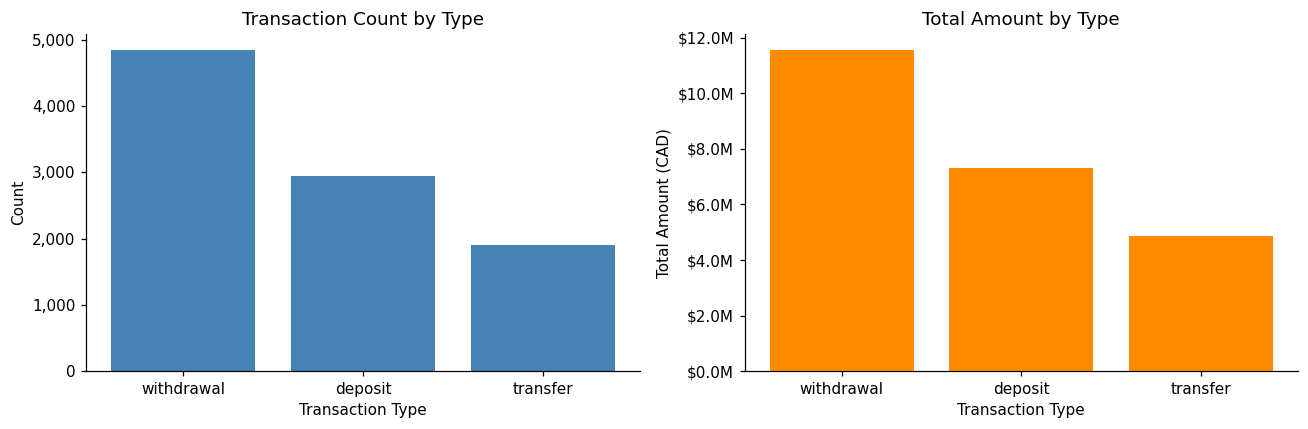

In [0]:
# Grouped bar chart: compare transaction count and total amount by type

type_summary = (
    transactions_df.groupby("transaction_type")[["amount"]]
    .agg(["count", "sum"])
    .reset_index()
)
type_summary.columns = ["transaction_type", "count", "total_amount"]
type_summary = type_summary.sort_values("total_amount", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Transaction count
ax1.bar(type_summary["transaction_type"], type_summary["count"], color="steelblue")
ax1.set_title("Transaction Count by Type")
ax1.set_xlabel("Transaction Type")
ax1.set_ylabel("Count")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Total amount
ax2.bar(type_summary["transaction_type"], type_summary["total_amount"], color="darkorange")
ax2.set_title("Total Amount by Type")
ax2.set_xlabel("Transaction Type")
ax2.set_ylabel("Total Amount (CAD)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))

plt.tight_layout()
plt.show()

### Monthly Transaction Trend

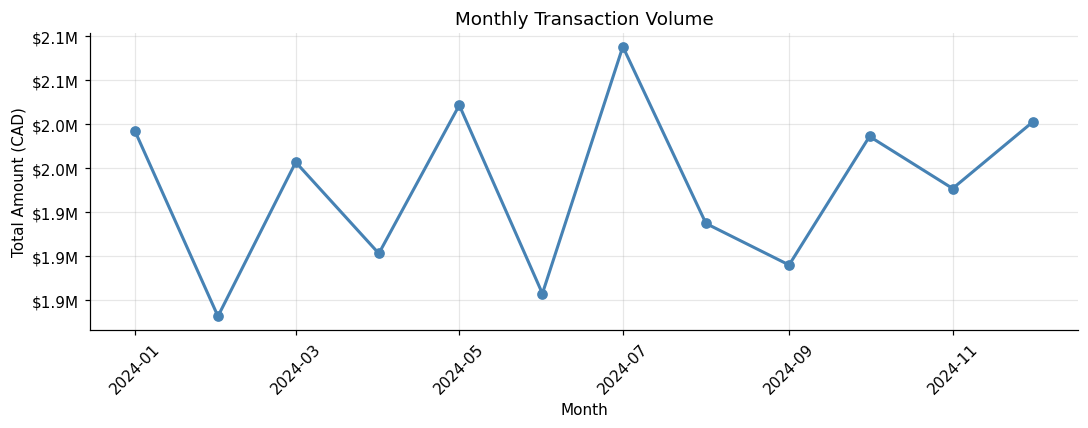

In [0]:
# Line chart: transaction volume by month to reveal trends

transactions_df["year_month"] = pd.to_datetime(
    transactions_df["transaction_year"].astype(str) + "-" + 
    transactions_df["transaction_month"].astype(str).str.zfill(2) + "-01"
)

monthly_trend = (
    transactions_df.groupby("year_month")["amount"]
    .agg(["count", "sum"])
    .sort_index()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_trend["year_month"], monthly_trend["sum"], 
        marker="o", linewidth=2, color="steelblue")
ax.set_title("Monthly Transaction Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount (CAD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Segment Distribution

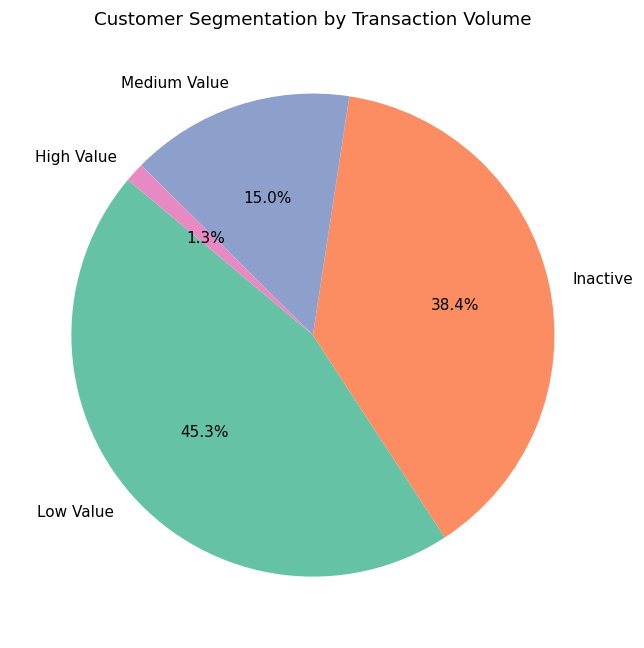

In [0]:
# Pie chart: proportion of customers in each segment

segment_dist = customer_df["customer_segment"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(
    segment_dist,
    labels=segment_dist.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set2.colors,
)
ax.set_title("Customer Segmentation by Transaction Volume")
plt.tight_layout()
plt.show()

### Distribution of Customer Age

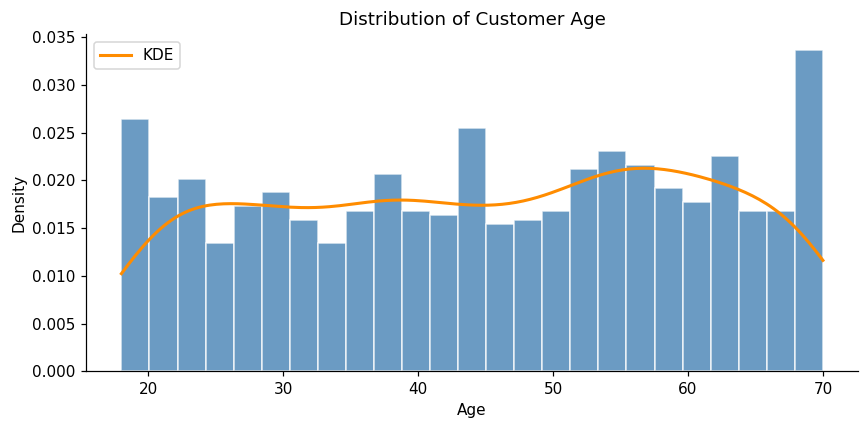

In [0]:
# Histogram with a KDE overlay: understand customer age distribution

ages = customer_df["age"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=25, color="steelblue", edgecolor="white", alpha=0.8, density=True)

# Overlay a smooth KDE curve
kde     = gaussian_kde(ages)
x_range = np.linspace(ages.min(), ages.max(), 200)
ax.plot(x_range, kde(x_range), color="darkorange", linewidth=2, label="KDE")

ax.set_title("Distribution of Customer Age")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

### Transaction Amount by Income Bracket

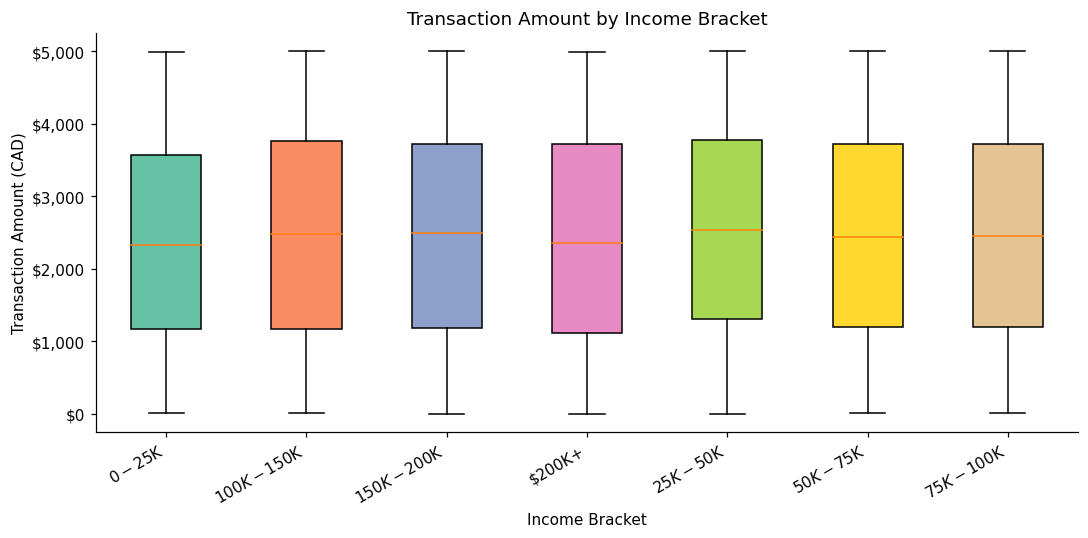

In [0]:
# Box plot: transaction amount distribution across income brackets

income_brackets = transactions_df["income_bracket"].unique()
income_order = sorted(income_brackets, key=lambda x: x)  # Simple alphabetical sort

data_by_income = [
    transactions_df.loc[transactions_df["income_bracket"] == ib, "amount"].dropna().values
    for ib in income_order
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_income, labels=income_order, patch_artist=True)
for patch, color in zip(bp["boxes"], plt.cm.Set2.colors):
    patch.set_facecolor(color)

ax.set_title("Transaction Amount by Income Bracket")
ax.set_xlabel("Income Bracket")
ax.set_ylabel("Transaction Amount (CAD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Loan Approval Rate by Loan Type

20:36:34  INFO  Loaded sandbox_catalog.banking_details.loan_applications_silver (558 rows)


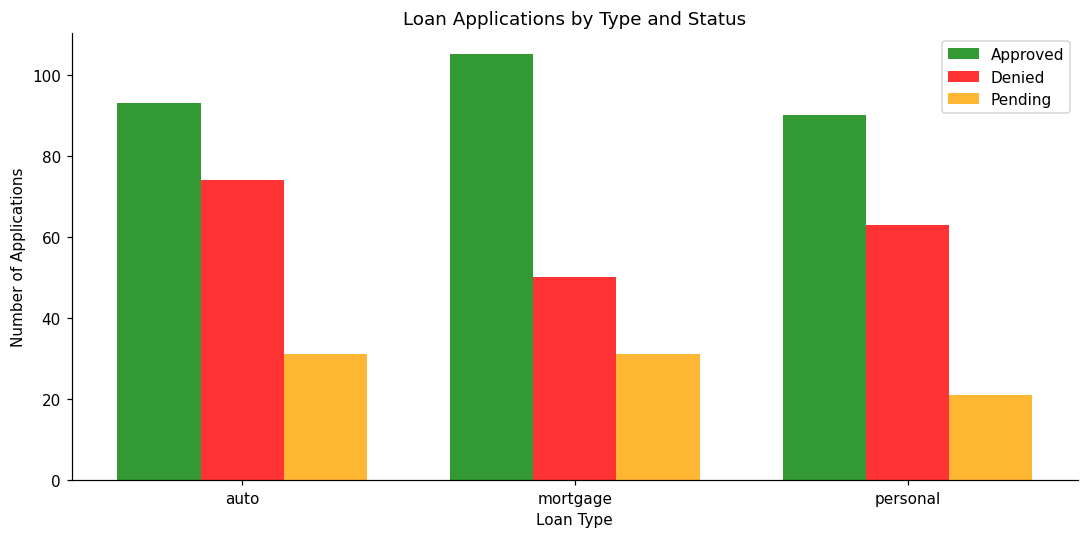

In [0]:
# Grouped bar chart: compare approval rates across loan types

# Filter customers who applied for loans
loan_customers = customer_df[customer_df["total_loan_applications"] > 0].copy()

if len(loan_customers) > 0:
    # We need to go back to the loan_applications table to get loan_type
    loan_apps = read_table("loan_applications_silver").toPandas()
    
    loan_summary = (
        loan_apps.groupby(["loan_type", "status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Calculate approval rate
    if "approved" in loan_summary.columns and "denied" in loan_summary.columns:
        loan_summary["approval_rate"] = (
            loan_summary["approved"] / 
            (loan_summary["approved"] + loan_summary["denied"]) * 100
        )
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(loan_summary))
    width = 0.25
    
    if "approved" in loan_summary.columns:
        ax.bar(x - width, loan_summary["approved"], width, label="Approved", color="green", alpha=0.8)
    if "denied" in loan_summary.columns:
        ax.bar(x, loan_summary["denied"], width, label="Denied", color="red", alpha=0.8)
    if "pending" in loan_summary.columns:
        ax.bar(x + width, loan_summary["pending"], width, label="Pending", color="orange", alpha=0.8)
    
    ax.set_title("Loan Applications by Type and Status")
    ax.set_xlabel("Loan Type")
    ax.set_ylabel("Number of Applications")
    ax.set_xticks(x)
    ax.set_xticklabels(loan_summary["loan_type"])
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No loan application data available for visualization.")

### Top 10 Customers by Total Transaction Amount

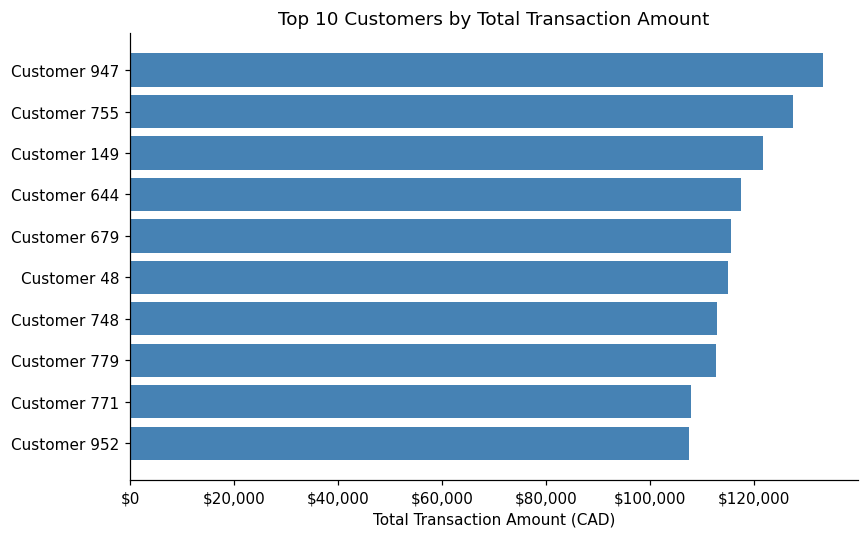

In [0]:
# Horizontal bar chart: identify highest-value customers

top10 = (
    customer_df[["customer_id", "total_transaction_amount"]]
    .sort_values("total_transaction_amount", ascending=False)
    .head(10)
)

# Create customer labels
top10["customer_label"] = top10["customer_id"].apply(lambda x: f"Customer {x}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["customer_label"], top10["total_transaction_amount"], color="steelblue")
ax.invert_yaxis()   # highest value at the top
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_title("Top 10 Customers by Total Transaction Amount")
ax.set_xlabel("Total Transaction Amount (CAD)")
plt.tight_layout()
plt.show()

### Customer Distribution by Province

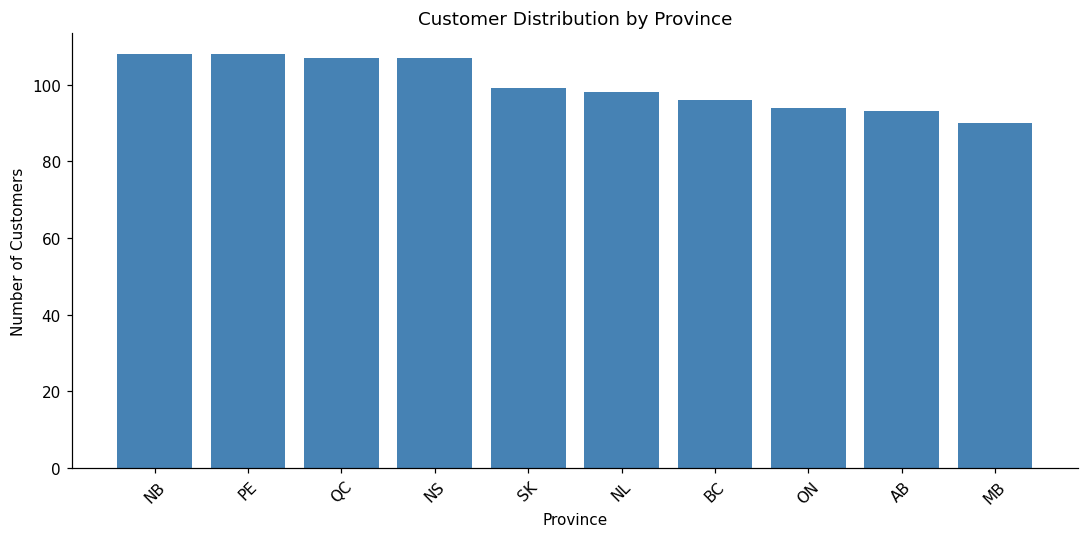

In [0]:
# Bar chart: customer count by province

province_dist = customer_df["province"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(province_dist.index, province_dist.values, color="steelblue")
ax.set_title("Customer Distribution by Province")
ax.set_xlabel("Province")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap — Customer Metrics

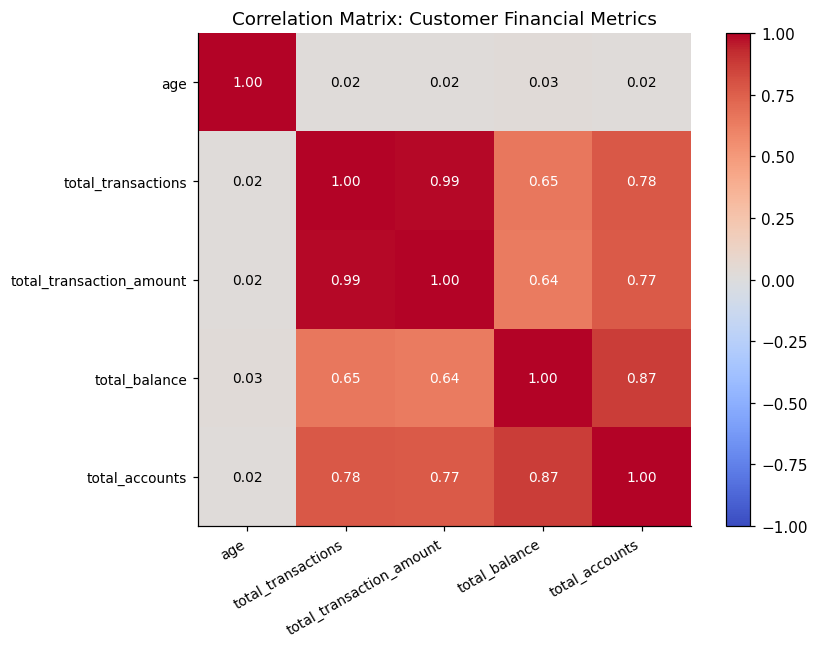

In [0]:
# Heatmap: visualize linear relationships between customer-level metrics

corr_cols = [
    "age", "total_transactions", "total_transaction_amount", 
    "total_balance", "total_accounts"
]
corr_matrix = customer_df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotate each cell with its correlation value
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

ax.set_title("Correlation Matrix: Customer Financial Metrics")
plt.tight_layout()
plt.show()